# Rectified Image Processing for Thermal Landscapes Project
 PB 6/6/2022
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

In [1]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

In [2]:
# Define inputs
img_dir = Path('/n/davies_lab/Lab/data/products/2020_01-02/MakhEP/raster/thermal/rectifiedimages')
# shp_f = Path('./data/in/MakhEP_SampleExclosurePolygons_WGS84UTM36S/MakhEP_SampleExclosurePolygons_WGS84UTM36S.shp')
shp_f = Path('./data/in/MakhEP_ExclosurePolygon_AD/Makhohlola_polygon.shp')


<AxesSubplot:>

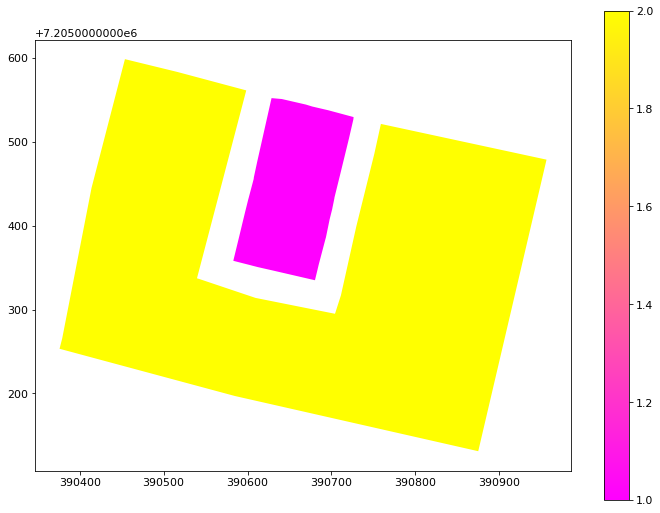

In [3]:
# Load shapefile
shp = gpd.read_file(shp_f)
# Loop thru images
# for i in img_dir.glob('*.tif'):
shp.plot(column='id',cmap='spring', legend=True)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


(390346.9831382704, 390985.2995488901, 7205104.838433071, 7205657.4)

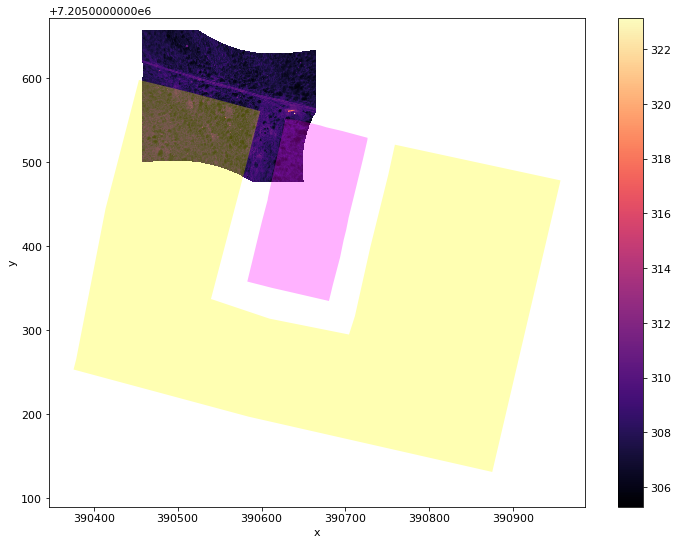

In [4]:
# Make list of images
img_fs = [i for i in img_dir.glob('*.tif')]
# Load image
f = img_fs[0]
img = rioxr.open_rasterio(f,
                          parse_coordinates=True,
                          masked=True)

# extract the temp band and convert to kelvin
img_k = (img.sel(band=4)*0.04)

# filter 0 degree C and below as nans
img_k = img_k.where(img_k > 273.15)

fig, ax = plt.subplots()
img_k.plot(ax=ax, cmap='magma')
shp.plot(column='id', alpha=0.3, ax=ax, cmap='spring')
ax.set_title('')
ax.axis('equal')

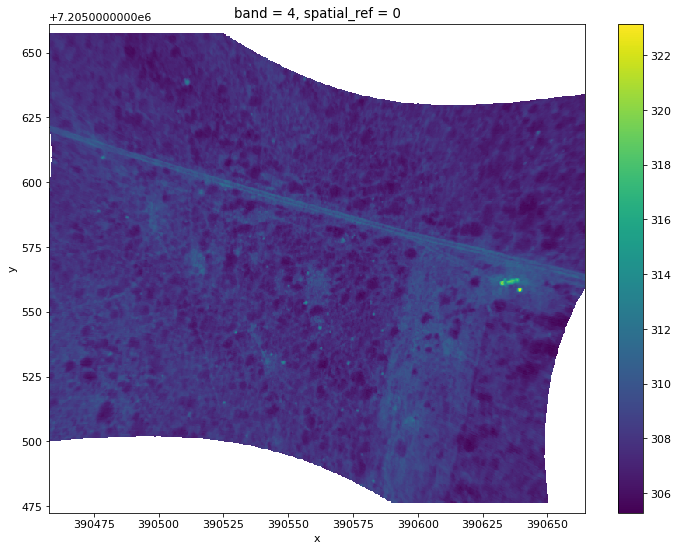

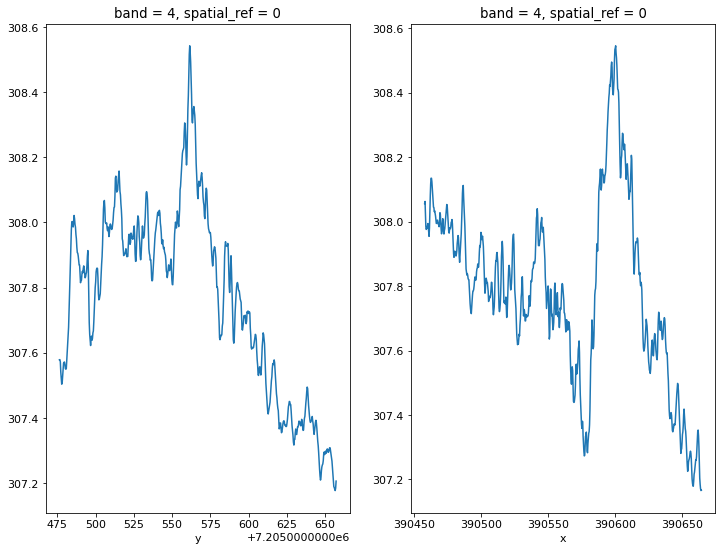

In [41]:
# Check how temperature varies across the image
# using xarrays plotting: https://docs.xarray.dev/en/stable/user-guide/plotting.html
# And xarrays split-apply-combine: https://docs.xarray.dev/en/stable/user-guide/groupby.html
img_groupY = img_k.groupby('y')
img_group_meanY = img_groupY.apply(np.mean)
img_groupX = img_k.groupby('x')
img_group_meanX = img_groupX.apply(np.mean)
# img_groupY_mean.plot.line(x='x')
fig, ax = plt.subplots()
img_k.plot(ax=ax)
ax.axis('equal')
fig, (ax1, ax2) = plt.subplots(1, 2)
img_group_meanY.plot(ax=ax1)
img_group_meanX.plot(ax=ax2)

1: 307.2403259277344
2: 307.8953857421875


Text(0.5, 1.0, 'Polygon ID: 2')

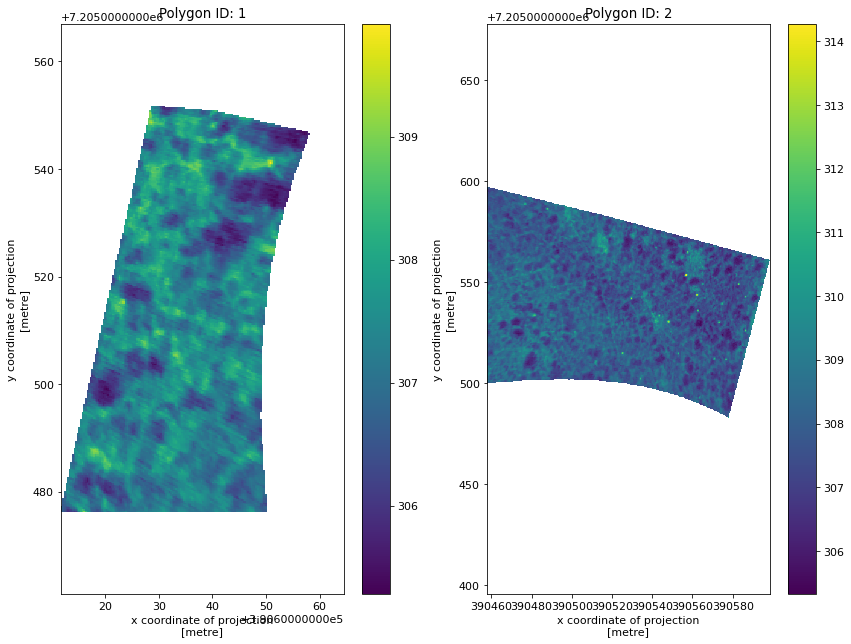

In [58]:
# Define polygon of bounds of img
minx, miny, maxx, maxy = img.rio.bounds()

x_list = [minx, maxx,
          maxx, minx,
          minx]
y_list = [maxy, maxy,
          miny, miny,
          maxy]

polygon_geom = Polygon(zip(x_list, y_list))
clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[polygon_geom])

# Make a dictionary for storing data
pixel_dict.clear()
pixel_dict = dict.fromkeys(shp.id, [])
# pixel_dict = {}
# for ID in shp.id:
#     pixel_dict[id] =[]

# Plotting:
fig, (ax1, ax2) = plt.subplots(1,2)

# loop through features in shapefile
# and test whether an img overlaps with them
# and if so, if it has real values in both (not nans)
for ID, feature, ax in zip(shp.id, shp.geometry, [ax1, ax2]):
    if clipbox.intersects(feature)[0]:
        
        # Get the intersection, and clip your raster with it
        pixels = img_k.rio.clip(clipbox.intersection(feature), drop=True)
        
        # If any of the data is not nan
        if np.isfinite(pixels.data).any():
            
            # Plot it
            pixels.plot(ax=ax)
            ax.axis('equal')
            ax.set_title('')
        
            # Store it in a dict
            pixel_dict[ID].append(pixels.data)
            print(f'{ID}: {np.nanmean(pixels.data.flatten())}')
            

fig.tight_layout()
ax1.set_title(f'Polygon ID: {shp.id[0]}')
ax2.set_title(f'Polygon ID: {shp.id[1]}')

In [65]:
np.shape(pixel_dict[1][0])

(252, 176)

In [66]:
img_k.shape

(604, 689)

In [19]:
# Calc stats
# for ID in shp.id:
#     df = pd.DataFrame(pixel_dict[ID])
#     df.describe()
# np.mean(pixel_dict['1'])

In [20]:
pixel_dict

{1: [array([[      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         ...,
         [306.8    , 306.68   , 306.52   , ...,       nan,       nan,
                nan],
         [306.8    , 306.63998, 306.44   , ...,       nan,       nan,
                nan],
         [306.72   , 306.63998, 306.4    , ...,       nan,       nan,
                nan]], dtype=float32),
  array([[308.63998, 308.68   ,       nan, ...,       nan,       nan,
                nan],
         [308.72   , 308.52   , 308.12   , ...,       nan,       nan,
                nan],
         [308.52   , 308.75998, 308.32   , ...,       nan,       nan,
                nan],
         ...,
         [      nan,       nan,       nan, ...,       nan,       nan,
                nan],
         [      nan,       nan, 